# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Ayan Dhar |
| **Role** | Anomaly Investigation & Random Forest Model |
| **Notebook** | `Ayan_Anomalies_and_RandomForest.ipynb` |

## Notebook Summary

1. Anomaly Investigation (zero-reading streaks, Site 0 electricity deep-dive, extreme outliers, sudden jumps)
2. Baseline Median Model and per-meter RMSLE evaluation
3. Random Forest training and `RandomizedSearchCV` tuning
4. CatBoost tuning

**Notes on this notebook.** The anomaly investigation, the Sprint-2 baseline median model, and the Random Forest and CatBoost training and tuning were authored by Ayan. During team integration, Zahra refactored path handling, corrected the baseline evaluation logic, and applied the project-wide RMSLE log-scale convention (commit `79e4729` and follow-ups). Wahid contributed variable-name and directory-path cleanup. Tanisha pushed one Sprint-3 tuning update on Ayan's behalf.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/merged_train.csv')

# Display the first few rows of the DataFrame
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.0,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.0,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.0,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.0,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['building_id', 'meter', 'timestamp'], ascending=[True, True, True])
df = df.reset_index(drop=True)
df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
import numpy as np

# 1. Boolean series for exactly 0 readings
is_zero = df['meter_reading'] == 0

# 2. Streak identifier: cumulative sum of non-zero readings
streak_id = (~is_zero).cumsum()

# 3. Add streak_id to dataframe temporarily to group
df['streak_id'] = streak_id

# 4. Filter only the rows where the reading is 0
zero_df = df[is_zero]

# Group by building_id, meter, and streak_id, then calculate the size of each group
zero_streaks = zero_df.groupby(['building_id', 'meter', 'streak_id']).size().reset_index(name='streak_length')

# Drop the temporary streak_id column from the original dataframe
df = df.drop(columns=['streak_id'])

# Display the top 5 longest zero streaks
zero_streaks.sort_values('streak_length', ascending=False).head()


,building_id,meter,streak_id,streak_length
39420,1160,1,5233449,3571
39896,1169,0,5294106,3571
1032,45,0,26565,3571
12013,287,3,1212069,3571
35596,1072,2,4685772,3571


In [ ]:
import pandas as pd

# Filter for streaks longer than 168 hours
anomalous_streaks = zero_streaks[zero_streaks['streak_length'] > 168]

# Extract unique building_id and meter pairs
anomalous_pairs = anomalous_streaks[['building_id', 'meter']].drop_duplicates().reset_index(drop=True)

# Display the first few anomalous pairs
anomalous_pairs.head()

,building_id,meter
0,0,0
1,2,0
2,3,0
3,4,0
4,5,0


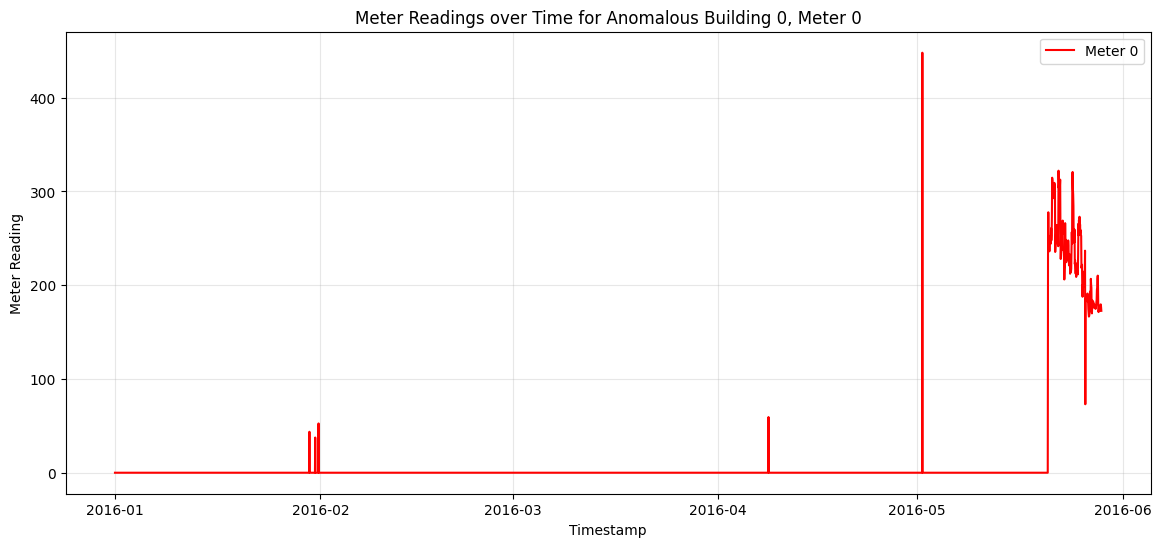

In [ ]:
import matplotlib.pyplot as plt

# 1. Select a sample building_id and meter pair from anomalous_pairs
sample_building_id = anomalous_pairs.iloc[0]['building_id']
sample_meter = anomalous_pairs.iloc[0]['meter']

# 2. Filter the main df DataFrame
sample_df = df[(df['building_id'] == sample_building_id) & (df['meter'] == sample_meter)]

# 4. Create a line plot
plt.figure(figsize=(14, 6))
plt.plot(sample_df['timestamp'], sample_df['meter_reading'], label=f'Meter {sample_meter}', color='red')

# 5. Add title, labels, and legend
plt.title(f'Meter Readings over Time for Anomalous Building {sample_building_id}, Meter {sample_meter}')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Display the plot
plt.show()

In [ ]:
# Filter for site_id 0 and meter 0 (electricity)
site0_elec_mask = (df['site_id'] == 0) & (df['meter'] == 0)

# Filter for the specific timeframe (2016-01-01 to 2016-05-31 inclusive)
time_mask = (df['timestamp'] >= '2016-01-01') & (df['timestamp'] <= '2016-05-31 23:59:59')

# Combine masks and apply to the dataframe
site0_elec_df = df[site0_elec_mask & time_mask].copy()

# Display the first few rows
site0_elec_df.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


In [ ]:
# Extract the date component from the timestamp
site0_elec_df['date'] = site0_elec_df['timestamp'].dt.date

# Group by date and calculate the mean meter_reading
daily_site0_elec = site0_elec_df.groupby('date')['meter_reading'].mean().reset_index()

# Display the first few rows
daily_site0_elec.head()


,date,meter_reading
0,2016-01-01,0.857650
1,2016-01-02,1.344947
2,2016-01-03,2.546491
3,2016-01-04,1.009289
4,2016-01-05,0.689684


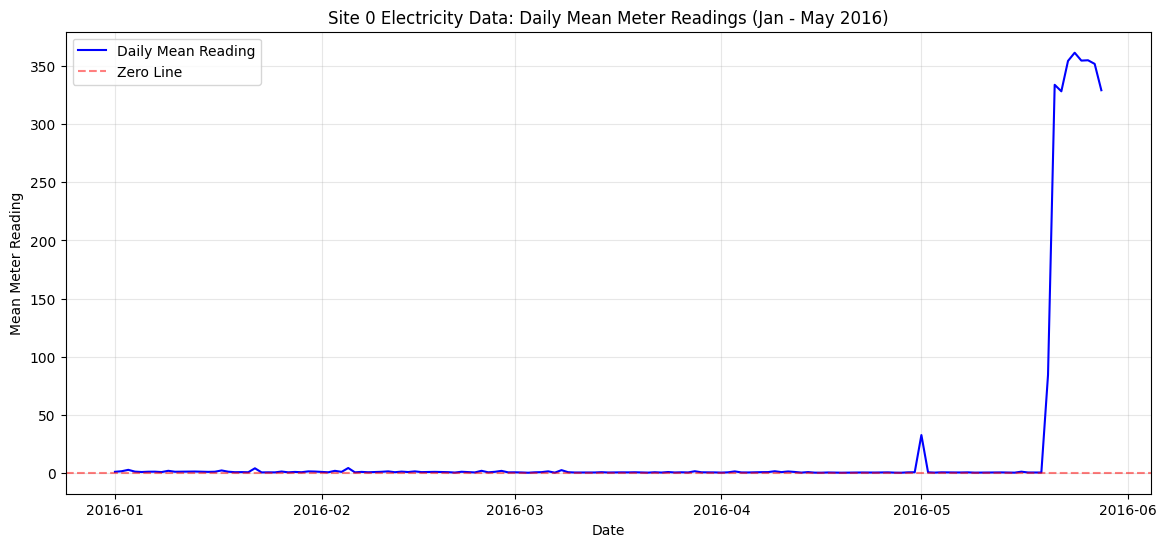

Total days analyzed: 149
Number of days with a mean reading of 0: 0
Percentage of days with missing/zero data: 0.00%


In [ ]:
import matplotlib.pyplot as plt

# Plot the daily aggregated meter readings
plt.figure(figsize=(14, 6))
plt.plot(daily_site0_elec['date'], daily_site0_elec['meter_reading'], color='blue', label='Daily Mean Reading')
plt.title('Site 0 Electricity Data: Daily Mean Meter Readings (Jan - May 2016)')
plt.xlabel('Date')
plt.ylabel('Mean Meter Reading')
plt.axhline(0, color='red', linestyle='--', alpha=0.5, label='Zero Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Quantify anomalous (zero) readings
zero_days = daily_site0_elec[daily_site0_elec['meter_reading'] == 0]
num_zero_days = len(zero_days)
total_days = len(daily_site0_elec)

print(f"Total days analyzed: {total_days}")
print(f"Number of days with a mean reading of 0: {num_zero_days}")
print(f"Percentage of days with missing/zero data: {(num_zero_days / total_days) * 100:.2f}%")


In [ ]:
# Filter for exact zero readings in the Site 0 electricity data
hourly_zeros = site0_elec_df[site0_elec_df['meter_reading'] == 0.0]

# Display the first few rows to inspect the anomalous timestamps
hourly_zeros.head()


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,date
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,2016-01-01
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,2016-01-01
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,2016-01-01
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,2016-01-01
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,2016-01-01


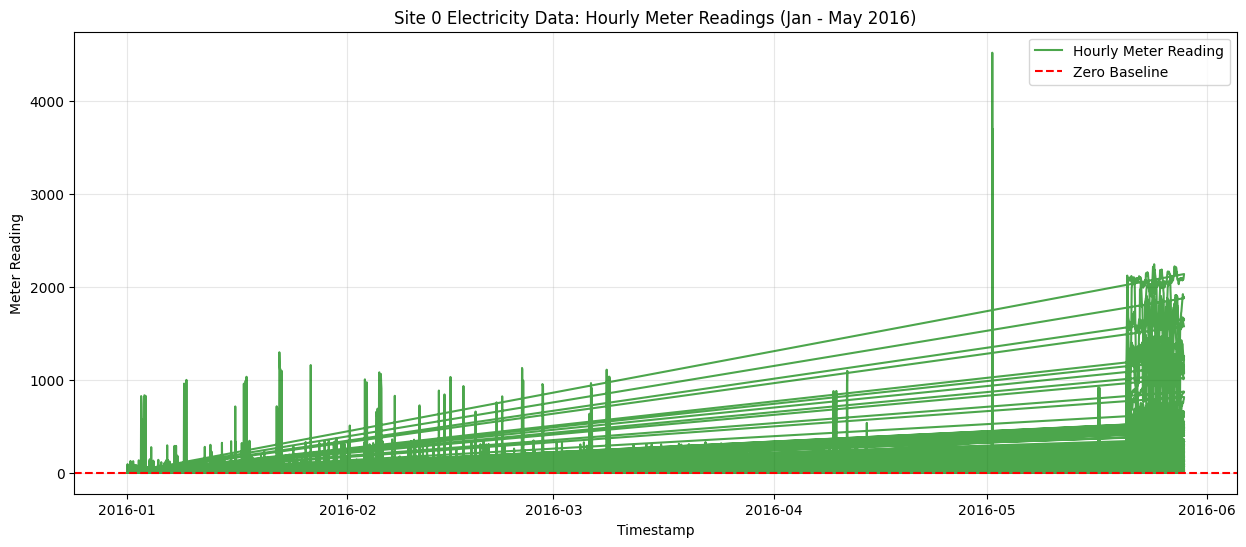

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with an appropriate size
plt.figure(figsize=(15, 6))

# Plot the hourly timestamp and meter_reading for Site 0 electricity
plt.plot(site0_elec_df['timestamp'], site0_elec_df['meter_reading'], label='Hourly Meter Reading', color='green', alpha=0.7)

# Add title and labels
plt.title('Site 0 Electricity Data: Hourly Meter Readings (Jan - May 2016)')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')

# Add a horizontal line at y=0 to highlight the zero-reading regions
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Baseline')

# Add a legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

In [ ]:
# 1. Total number of zero readings
num_zero_hours = len(hourly_zeros)
total_hours = len(site0_elec_df)

# 2. Percentage of the timeframe affected
percentage_affected = (num_zero_hours / total_hours) * 100

# 3. Find continuous streaks of zero hours
is_zero_hr = site0_elec_df['meter_reading'] == 0.0
streak_id_hr = (~is_zero_hr).cumsum()

# Group by streak_id to find the lengths of continuous zero streaks
zero_hr_streaks = site0_elec_df[is_zero_hr].groupby(streak_id_hr).size().reset_index(name='streak_length')

# Print the summary statistics
print(f"Total hours analyzed: {total_hours}")
print(f"Number of hours with a reading of exactly 0: {num_zero_hours}")
print(f"Percentage of hours with missing/zero data: {percentage_affected:.2f}%")
print("\nZero Reading Streaks (Hourly):")
print(zero_hr_streaks['streak_length'].value_counts().sort_index(ascending=False))

Total hours analyzed: 367794
Number of hours with a reading of exactly 0: 344825
Percentage of hours with missing/zero data: 93.75%

Zero Reading Streaks (Hourly):
streak_length
6259     1
3571     1
2926     1
2923    58
2719     1
        ..
5       84
4       56
3       96
2       57
1       86
Name: count, Length: 246, dtype: int64


In [ ]:
threshold_999 = df['meter_reading'].quantile(0.999)
print(f"99.9th percentile threshold: {threshold_999}")

99.9th percentile threshold: 47043.920400005576


In [ ]:
outliers_df = df[df['meter_reading'] > threshold_999]

affected_buildings = outliers_df['building_id'].unique()

print(f"Total number of outlier readings: {len(outliers_df)}")
print(f"Unique building IDs affected: {affected_buildings}")


Total number of outlier readings: 8030
Unique building IDs affected: [  60  993 1021 1099 1148 1159 1168 1197]


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 8))
colors = plt.cm.tab10.colors

for i, (building_id, group) in enumerate(outliers_df.groupby('building_id')):
    ax.scatter(
        group['timestamp'],
        group['meter_reading'],
        label=str(building_id),
        color=colors[i % len(colors)],
        s=50,
        alpha=0.7,
    )

ax.set_title('Extreme Outliers: Meter Readings > 99.9th Percentile')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Meter Reading')
ax.legend(title='Building ID', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [ ]:
# Calculate the previous hour's meter reading by shifting within groups
df['prev_meter_reading'] = df.groupby(['building_id', 'meter'])['meter_reading'].shift(1)

# Display the first few rows to verify the new column
df.head()


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,prev_meter_reading
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,NaN
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008.0,NaN,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,0.0
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008.0,NaN,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008.0,NaN,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008.0,NaN,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,0.0


In [ ]:
# 1. Filter out cases where the previous reading was 0
non_zero_prev = df[df['prev_meter_reading'] > 0]

# 2. Identify instances where the current reading is strictly greater than 10 times the previous reading
sudden_jumps_df = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']]

# 4. Print the total number of sudden jumps detected
num_sudden_jumps = len(sudden_jumps_df)
print(f"Total number of sudden jumps detected: {num_sudden_jumps}")

# Display the first few rows of the identified sudden jumps
sudden_jumps_df.head()

Total number of sudden jumps detected: 13561


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,prev_meter_reading
37888,9,1,2016-03-01 06:00:00,590.945,0,Office,27000,2010.0,NaN,13.9,2.0,12.2,0.0,1021.1,0.0,0.0,42.2104
37912,9,1,2016-03-02 06:00:00,675.366,0,Office,27000,2010.0,NaN,15.0,0.0,11.7,0.0,1018.0,200.0,1.5,42.2104
38199,9,1,2016-03-14 05:00:00,1646.200,0,Office,27000,2010.0,NaN,22.8,NaN,18.9,0.0,1015.9,220.0,3.1,42.2104
38367,9,1,2016-03-21 05:00:00,844.207,0,Office,27000,2010.0,NaN,18.3,NaN,10.6,0.0,1014.7,300.0,7.2,42.2104
38392,9,1,2016-03-22 06:00:00,590.945,0,Office,27000,2010.0,NaN,7.8,2.0,4.4,0.0,1026.4,0.0,0.0,42.2104


In [ ]:
# Filter out cases where the previous reading was 0
non_zero_prev = df[df['prev_meter_reading'] > 0]

# Identify instances where the current reading is strictly greater than 10 times the previous reading
sudden_jumps_df = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']]

# Group by building_id and meter, then count the occurrences of sudden jumps
jump_counts = sudden_jumps_df.groupby(['building_id', 'meter']).size().reset_index(name='jump_count')

# Sort the results in descending order to find the most affected pairs
top_jump_pairs = jump_counts.sort_values(by='jump_count', ascending=False).head()

print("Top affected building and meter pairs:")
display(top_jump_pairs)


Top affected building and meter pairs:


,building_id,meter,jump_count
428,931,2,368
804,1301,3,363
688,1224,3,292
807,1305,2,241
561,1021,3,208


In [ ]:
# Memory efficient loading - only few columns getting loaded again for calculating sudden jumps due to RAM crashing issues
# Please consider the below sudden jump count for consideration.

import pandas as pd

# Define the datatypes for the columns to be loaded
dtypes = {
    'building_id': 'int32',
    'meter': 'int32',
    'meter_reading': 'float32'
}

# Specify the columns to load
cols_to_use = ['building_id', 'meter', 'timestamp', 'meter_reading']

# Load the data from the CSV file
df = pd.read_csv('/content/merged_train.csv', usecols=cols_to_use, dtype=dtypes)

# Verify the memory usage and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8029383 entries, 0 to 8029382
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   building_id    int32  
 1   meter          int32  
 2   timestamp      object 
 3   meter_reading  float32
dtypes: float32(1), int32(2), object(1)
memory usage: 153.1+ MB


In [ ]:
import gc

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort the DataFrame
df.sort_values(by=['building_id', 'meter', 'timestamp'], inplace=True)

# Force garbage collection
gc.collect()

# Calculate the previous hour's reading
df['prev_meter_reading'] = df.groupby(['building_id', 'meter'])['meter_reading'].shift(1)

# Force garbage collection again
gc.collect()

# Display the first few rows
df.head()


,building_id,meter,timestamp,meter_reading,prev_meter_reading
0,0,0,2016-01-01 00:00:00,0.0,NaN
2301,0,0,2016-01-01 01:00:00,0.0,0.0
4594,0,0,2016-01-01 02:00:00,0.0,0.0
6893,0,0,2016-01-01 03:00:00,0.0,0.0
9189,0,0,2016-01-01 04:00:00,0.0,0.0


In [ ]:
# 1. Filter out cases where the previous reading was 0
non_zero_prev = df[df['prev_meter_reading'] > 0]

# 2. Identify sudden jumps
sudden_jumps_df = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']]

# 3. Print the total number of sudden jumps detected
print(f"Total number of sudden jumps detected: {len(sudden_jumps_df)}")

# 4. Group by building_id and meter, then count the occurrences of sudden jumps
jump_counts = sudden_jumps_df.groupby(['building_id', 'meter']).size().reset_index(name='jump_count')

# 5. Sort the results in descending order to find the most affected pairs
top_jump_pairs = jump_counts.sort_values(by='jump_count', ascending=False).head()

print("\nTop affected building and meter pairs:")
display(top_jump_pairs)


Total number of sudden jumps detected: 13566

Top affected building and meter pairs:


,building_id,meter,jump_count
428,931,2,368
804,1301,3,363
688,1224,3,292
807,1305,2,241
561,1021,3,208


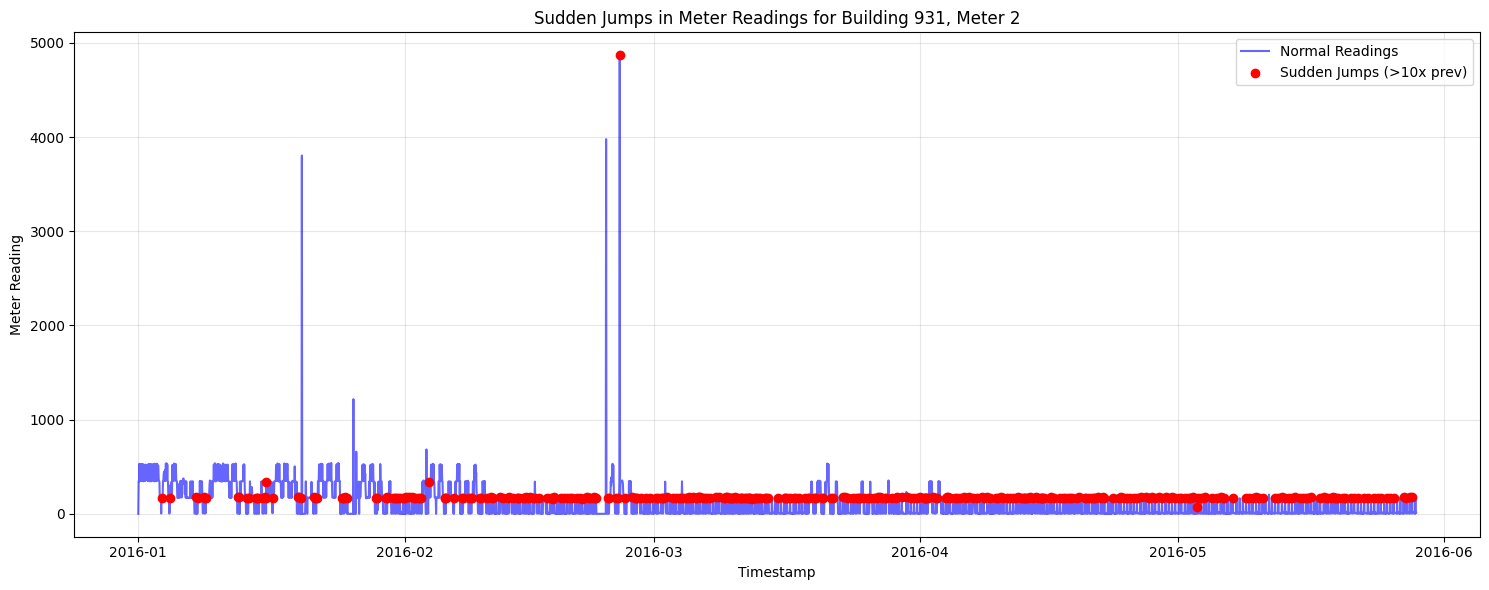

In [ ]:
import matplotlib.pyplot as plt

# Get the most affected building and meter pair
top_building_id = top_jump_pairs.iloc[0]['building_id']
top_meter = top_jump_pairs.iloc[0]['meter']

# Filter the original DataFrame for this specific pair
top_pair_df = df[(df['building_id'] == top_building_id) & (df['meter'] == top_meter)]

# Filter the sudden jumps DataFrame for this specific pair to highlight them
top_jumps_df = sudden_jumps_df[(sudden_jumps_df['building_id'] == top_building_id) & (sudden_jumps_df['meter'] == top_meter)]

# Create the plot
plt.figure(figsize=(15, 6))
plt.plot(top_pair_df['timestamp'], top_pair_df['meter_reading'], label='Normal Readings', color='blue', alpha=0.6)
plt.scatter(top_jumps_df['timestamp'], top_jumps_df['meter_reading'], color='red', label='Sudden Jumps (>10x prev)', zorder=5)

# Add labels, title, and legend
plt.title(f'Sudden Jumps in Meter Readings for Building {top_building_id}, Meter {top_meter}')
plt.xlabel('Timestamp')
plt.ylabel('Meter Reading')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 1. Create a boolean mask for exactly zero meter readings
is_zero = df['meter_reading'] == 0

# 2. Create a streak identifier by taking the cumulative sum of the negated mask
streak_id = (~is_zero).cumsum()

# 3. Filter the df to only include the zero readings
zero_readings_df = df[is_zero].copy()

# Add the streak_id to the filtered dataframe
zero_readings_df['streak_id'] = streak_id[is_zero]

# 4. Calculate the length of each streak using transform('size')
zero_readings_df['streak_length'] = zero_readings_df.groupby(['building_id', 'meter', 'streak_id'])['meter_reading'].transform('size')

# 5. Filter for streaks longer than 168 hours
zero_streak_anomalies = zero_readings_df[zero_readings_df['streak_length'] > 168]

# Display the number of anomalous rows found and a sample
print(f"Found {len(zero_streak_anomalies)} rows belonging to zero-reading streaks > 168 hours.")
zero_streak_anomalies.head()


Found 646381 rows belonging to zero-reading streaks > 168 hours.


,building_id,meter,timestamp,meter_reading,prev_meter_reading,streak_id,streak_length
0,0,0,2016-01-01 00:00:00,0.0,NaN,0,704
2301,0,0,2016-01-01 01:00:00,0.0,0.0,0,704
4594,0,0,2016-01-01 02:00:00,0.0,0.0,0,704
6893,0,0,2016-01-01 03:00:00,0.0,0.0,0,704
9189,0,0,2016-01-01 04:00:00,0.0,0.0,0,704


In [ ]:
import pandas as pd

# Recalculate the 99.9th percentile threshold for extreme outliers
threshold_999 = df['meter_reading'].quantile(0.999)

# Extract extreme outliers
extreme_outliers_df = df[df['meter_reading'] > threshold_999].copy()

# Re-filter for sudden jumps (>10x previous reading, non-zero previous)
non_zero_prev = df[df['prev_meter_reading'] > 0]
sudden_jumps_anomalies = non_zero_prev[non_zero_prev['meter_reading'] > 10 * non_zero_prev['prev_meter_reading']].copy()

print(f"Found {len(extreme_outliers_df)} extreme outliers.")
print(f"Found {len(sudden_jumps_anomalies)} sudden jumps.")


Found 8030 extreme outliers.
Found 13566 sudden jumps.


In [ ]:
import pandas as pd

# 1. Format zero_streak_anomalies
zero_formatted = zero_streak_anomalies.copy()
zero_formatted['anomaly_type'] = 'zero_streak'
zero_formatted['details'] = 'streak_length: ' + zero_formatted['streak_length'].astype(str) + ' hours'

# 2. Format extreme_outliers_df
outliers_formatted = extreme_outliers_df.copy()
outliers_formatted['anomaly_type'] = 'extreme_outlier'
outliers_formatted['details'] = 'exceeds_99.9th_percentile'

# 3. Format sudden_jumps_anomalies
jumps_formatted = sudden_jumps_anomalies.copy()
jumps_formatted['anomaly_type'] = 'sudden_jump'
jumps_formatted['details'] = 'prev_reading: ' + jumps_formatted['prev_meter_reading'].astype(str)

# 4. Subset to unified schema
unified_cols = ['anomaly_type', 'building_id', 'meter', 'timestamp', 'meter_reading', 'details']
zero_formatted = zero_formatted[unified_cols]
outliers_formatted = outliers_formatted[unified_cols]
jumps_formatted = jumps_formatted[unified_cols]

# 5. Concatenate DataFrames
combined_anomalies_df = pd.concat([zero_formatted, outliers_formatted, jumps_formatted], ignore_index=True)

# 6. Verify unification
print(f"Total number of rows in combined DataFrame: {len(combined_anomalies_df)}")
display(combined_anomalies_df.sample(10, random_state=42))


Total number of rows in combined DataFrame: 667977


,anomaly_type,building_id,meter,timestamp,meter_reading,details
316385,zero_streak,195,3,2016-04-28 05:00:00,0.0,streak_length: 2040 hours
453456,zero_streak,1028,1,2016-01-22 10:00:00,0.0,streak_length: 3171 hours
498468,zero_streak,1098,1,2016-01-25 16:00:00,0.0,streak_length: 2630 hours
16160,zero_streak,6,0,2016-03-03 14:00:00,0.0,streak_length: 2923 hours
258215,zero_streak,86,0,2016-02-14 23:00:00,0.0,streak_length: 1519 hours
571419,zero_streak,1216,1,2016-01-10 12:00:00,0.0,streak_length: 2481 hours
134357,zero_streak,44,0,2016-02-15 02:00:00,0.0,streak_length: 2923 hours
298462,zero_streak,102,0,2016-03-12 05:00:00,0.0,streak_length: 2923 hours
436151,zero_streak,1001,1,2016-01-21 06:00:00,0.0,streak_length: 1519 hours
54530,zero_streak,19,0,2016-04-09 16:00:00,0.0,streak_length: 2923 hours


In [ ]:
# Export the combined anomalies DataFrame to a CSV file
combined_anomalies_df.to_csv('detailed_anomalies.csv', index=False)

# Summarize the total number of anomaly records compiled across all categories
print("Anomaly Summary:")
print(combined_anomalies_df['anomaly_type'].value_counts())
print(f"\nTotal Anomaly Records Compiled: {len(combined_anomalies_df)}")
print("Data successfully exported to 'detailed_anomalies.csv'.")

Anomaly Summary:
anomaly_type
zero_streak        646381
sudden_jump         13566
extreme_outlier      8030
Name: count, dtype: int64

Total Anomaly Records Compiled: 667977
Data successfully exported to 'detailed_anomalies.csv'.


# Anomaly Investigation Summary

## Anomaly Detection (Zero Reading Streaks)
### Key Findings
* Multiple `building_id` and `meter` pairs were identified with continuous zero meter readings lasting for more than 168 consecutive hours (1 week).
* `meter` 0 is heavily represented in these initial anomalies, particularly in buildings 0, 2, 3, 4, and 5.

### Insights & Next Steps
* **Investigate Root Causes**: These prolonged zero readings could indicate sensor failures, data logging errors, or actual building shutdowns.
* **Action**: Flag or impute these anomalous periods to prevent them from skewing predictive models or baseline consumption metrics.

## Calibration Gap Analysis (Site 0 Electricity)
### Key Findings
* A massive calibration gap exists for Site 0 electricity data between January and May 2016, with 93.75% (344,825 out of 367,794) of the hourly readings being exactly zero.
* Continuous streaks of zero readings were observed, the longest being 6,259 consecutive hours.

### Insights & Next Steps
* **Data Usability**: The Site 0 electricity data for the first five months of 2016 is fundamentally compromised.
* **Action**: Completely drop the Site 0 electricity data prior to May 2016 rather than attempting to impute this massive gap.

## Extreme Outliers
### Key Findings
* The 99.9th percentile threshold for `meter_reading` is approximately 47,043.92.
* A total of 8,030 individual meter readings exceeded this extreme threshold.
* These outliers are entirely isolated to just 8 specific buildings: 60, 993, 1021, 1099, 1148, 1159, 1168, and 1197.

### Insights & Next Steps
* **Investigation**: The concentration of extreme values in a few buildings suggests localized sensor malfunctions, unit conversion errors, or fundamentally different operations.
* **Action**: Clip these extreme values, drop the anomalous periods for these meters, or investigate raw data for unit conversion issues before modeling.

## Sudden Jumps in Meter Readings
### Key Findings
* Over 13,500 instances were detected where the current hourly meter reading was strictly greater than 10 times the previous non-zero reading.
* Specific building and meter pairs (e.g., Building 931, Meter 2; Building 1301, Meter 3) exhibited the highest frequency of these sudden anomalous spikes.

### Insights & Next Steps
* **Investigation**: Investigate these highly affected pairs for potential sensor malfunctions, telemetry errors, or extreme localized usage events.
* **Action**: Implement automated alerts or data validation thresholds to flag or quarantine readings exceeding 10x their previous hourly value in real-time pipelines.

*Note: the train/validation split for the median baseline was corrected during team integration to derive medians from training data only (commit `79e4729`); the RMSLE log-scale handling and project-relative paths were also applied here.*

In [1]:
import pandas as pd
#Load the training dataset
train_df = pd.read_csv(r'../data_processed/final_train_with_features.csv')
test_df = pd.read_csv(r'../data_processed/final_test_with_features.csv')

train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
train_df['hour'] = train_df['timestamp'].dt.hour
train_df['day_of_week'] = train_df['timestamp'].dt.dayofweek

test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])
test_df['hour'] = test_df['timestamp'].dt.hour
test_df['day_of_week'] = test_df['timestamp'].dt.dayofweek

# Calculate the median meter reading for each group
baseline_median = train_df.groupby(['building_id', 'meter', 'hour', 'day_of_week'])['meter_reading'].median().reset_index()

# Display the first few rows of the baseline model
display(baseline_median.head())

,building_id,meter,hour,day_of_week,meter_reading
0,1,0,0,0,137.8770
1,1,0,0,1,137.0580
2,1,0,0,2,136.7850
3,1,0,0,3,136.6485
4,1,0,0,4,137.8770


In [2]:
# Merge val_df with baseline_median to get the predicted median meter_reading
test_df = pd.merge(
    test_df,
    baseline_median,
    on=['building_id', 'meter', 'hour', 'day_of_week'],
    how='left',
    suffixes=('_actual', '_predicted')  # Suffixes to differentiate original and predicted meter_reading
)

# Display the first few rows with the predicted median
display(test_df.head())

,building_id,meter,timestamp,meter_reading_actual,site_id,floor_count,hour,day_of_week,month,day_of_year,...,precip_was_missing,relative_humidity,temp_diff_from_comfort,lag_24h,lag_72h,lag_168h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,meter_reading_predicted
0,1,0,2016-11-08 00:00:00,90.6440,0,2,0,1,11,313,...,0.0,65.569640,0.1,92.0091,131.3250,96.9235,89.961433,4.355004,104.257829,137.0580
1,1,0,2016-11-08 01:00:00,92.5552,0,2,1,1,11,313,...,0.0,67.617645,0.4,93.9203,127.5020,96.1045,89.904554,4.335970,104.220451,136.9215
2,1,0,2016-11-08 02:00:00,59.2462,0,2,2,1,11,313,...,0.0,67.617645,0.4,93.3742,128.8670,95.0124,89.847675,4.289708,104.199324,138.1500
3,1,0,2016-11-08 03:00:00,54.3318,0,2,3,1,11,313,...,0.0,67.617645,0.4,95.2854,91.4631,94.7394,88.425675,7.514394,103.986430,139.2420
4,1,0,2016-11-08 04:00:00,57.3351,0,2,4,1,11,313,...,0.0,72.938770,1.0,93.9203,96.3775,94.1933,86.719275,10.095573,103.745909,137.8770


In [3]:
import numpy as np

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

# RMSLE per Meter Type
rmsle_per_meter = test_df.groupby("meter").apply(
    lambda x: rmsle(x["meter_reading_actual"], x["meter_reading_predicted"])
).reset_index(name="RMSLE")

print("RMSLE per Meter Type:")
display(rmsle_per_meter)

overall_rmsle = rmsle(test_df["meter_reading_actual"], test_df["meter_reading_predicted"])
print("Overall RMSLE:", overall_rmsle)

RMSLE per Meter Type:


,meter,RMSLE
0,0,0.615688
1,1,1.967118
2,2,1.991482
3,3,2.128952


Overall RMSLE: 1.3254289914945556


In [4]:
import pandas as pd

results_table = pd.DataFrame([{"Model": "Baseline Median Model", "Overall RMSLE": overall_rmsle}])
display(results_table)

,Model,Overall RMSLE
0,Baseline Median Model,1.325429


In [5]:
results_table = results_table.drop_duplicates().reset_index(drop=True)
display(results_table)

,Model,Overall RMSLE
0,Baseline Median Model,1.325429


In [6]:
results_table.to_csv("../outputs/baseline_evaluation_results.csv", index=False)
print("Baseline results saved to outputs/baseline_evaluation_results.csv")

Baseline results saved to outputs/baseline_evaluation_results.csv


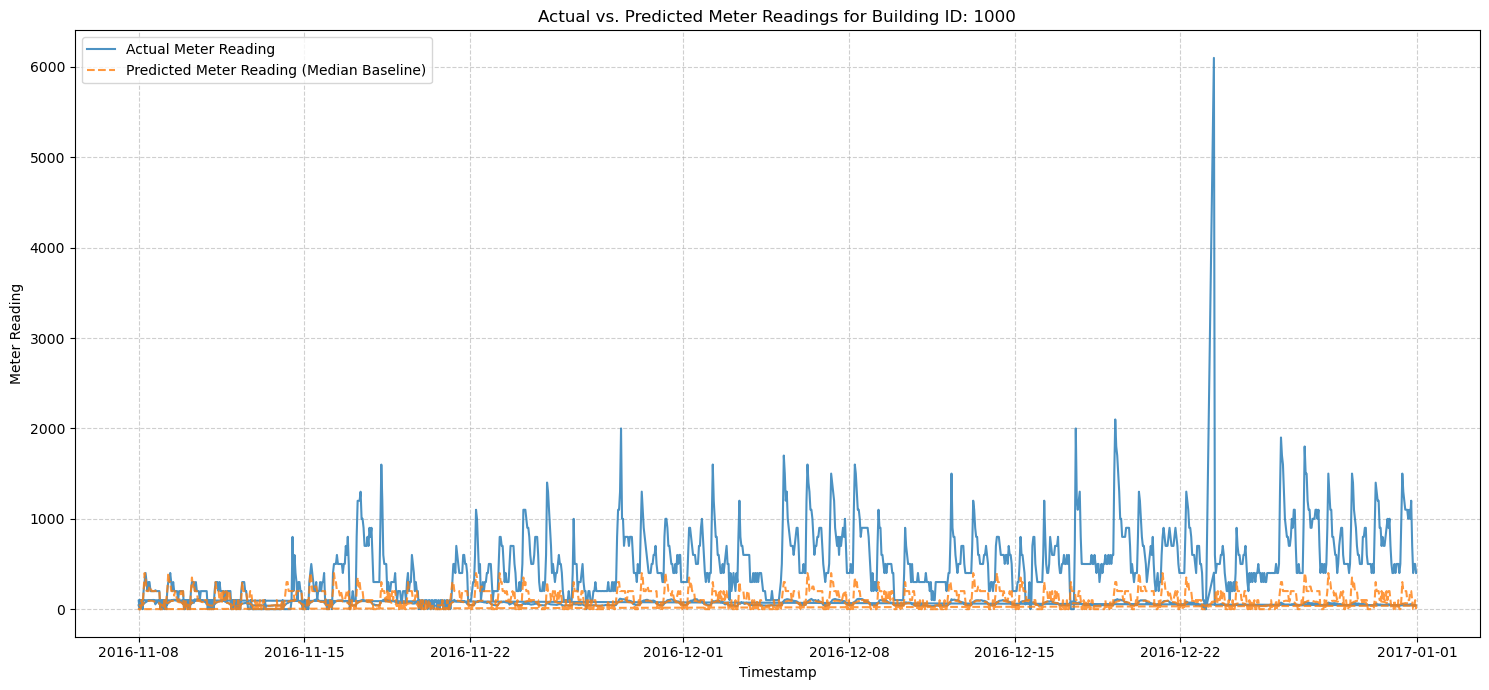

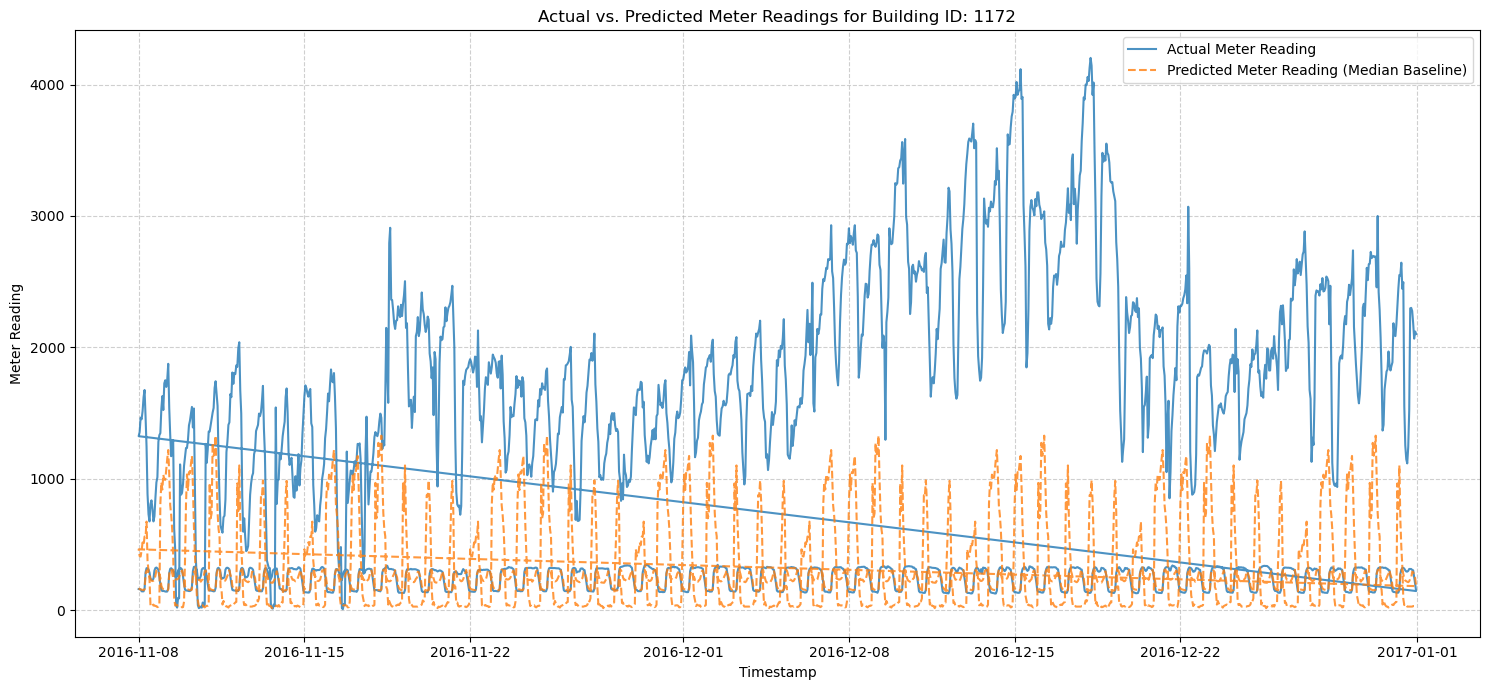

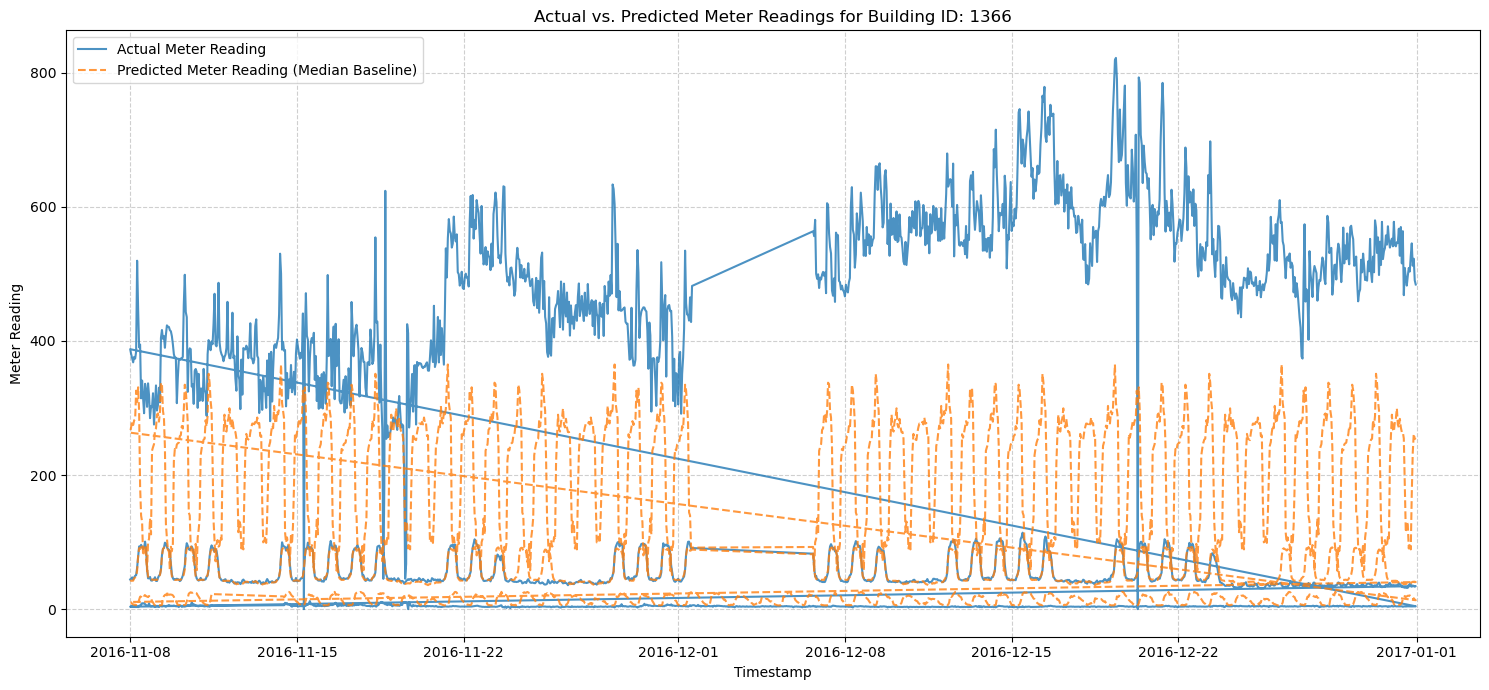

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique building_ids
unique_buildings = test_df['building_id'].unique()

# Select 3 random sample buildings (ensure there are at least 3 unique buildings)
num_samples = min(3, len(unique_buildings))
np.random.seed(42) # For reproducibility of sample selection
sample_buildings = np.random.choice(unique_buildings, num_samples, replace=False)

for building_id in sample_buildings:
    # Filter data for the current building
    building_df = test_df[test_df['building_id'] == building_id].copy()

    # Create the plot
    plt.figure(figsize=(15, 7))
    plt.plot(building_df['timestamp'], building_df['meter_reading_actual'], label='Actual Meter Reading', alpha=0.8)
    plt.plot(building_df['timestamp'], building_df['meter_reading_predicted'], label='Predicted Meter Reading (Median Baseline)', alpha=0.8, linestyle='--')

    plt.title(f'Actual vs. Predicted Meter Readings for Building ID: {building_id}')
    plt.xlabel('Timestamp')
    plt.ylabel('Meter Reading')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [10]:
import pandas as pd
train = pd.read_csv(r'../data_processed/final_train_with_features.csv')
test  = pd.read_csv(r'../data_processed/final_test_with_features.csv')

print("Train shape:", train.shape)
print("Columns:", list(train.columns))
print("Missing values:")
print(train.isnull().sum())
display(train.head(10))

Train shape: (14183013, 49)
Columns: ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'floor_count', 'hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading', 'missing_floor_count_flag', 'building_age', 'log_square_feet', 'use_Education', 'use_Entertainment/public assembly', 'use_Food sales and service', 'use_Healthcare', 'use_Lodging/residential', 'use_Manufacturing/industrial', 'use_Office', 'use_Other', 'use_Parking', 'use_Public services', 'use_Religious worship', 'use_Retail', 'use_Services', 'use_Technology/science', 'use_Utility', 'use_Warehouse/storage', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'precip_was_missing', 'relative_humidity', 'temp_diff_from_comfort', 'lag_24h', 'lag_72h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h']
Missing values:
building_id                          0
meter     

,building_id,meter,timestamp,meter_reading,site_id,floor_count,hour,day_of_week,month,day_of_year,...,wind_speed,precip_was_missing,relative_humidity,temp_diff_from_comfort,lag_24h,lag_72h,lag_168h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h
0,1,0,2016-05-27 00:00:00,93.3742,0,2,0,4,5,148,...,4.6,0.0,46.967575,5.1,92.8282,91.1900,0.0,105.103004,13.404664,101.747009
1,1,0,2016-05-27 01:00:00,97.4696,0,2,1,4,5,148,...,4.1,0.0,59.869198,3.4,94.1933,94.4663,0.0,105.125754,13.383373,102.302808
2,1,0,2016-05-27 02:00:00,98.5617,0,2,2,4,5,148,...,3.1,0.0,65.927980,1.8,93.9203,95.0124,0.0,105.262267,13.283347,102.882984
3,1,0,2016-05-27 03:00:00,100.2000,0,2,3,4,5,148,...,3.1,0.0,66.453170,2.3,94.7394,96.3775,0.0,105.455658,13.144098,103.469661
4,1,0,2016-05-27 04:00:00,100.4730,0,2,4,4,5,148,...,4.6,0.0,68.592510,2.3,95.0124,96.3775,0.0,105.683183,12.996972,104.066089
5,1,0,2016-05-27 05:00:00,98.0156,0,2,5,4,5,148,...,4.6,0.0,68.592510,2.3,94.7394,89.0059,0.0,105.910708,12.849001,104.664143
6,1,0,2016-05-27 06:00:00,98.0156,0,2,6,4,5,148,...,1.5,0.0,68.494070,1.8,94.7394,94.4663,0.0,106.047217,12.742115,105.247569
7,1,0,2016-05-27 07:00:00,99.1077,0,2,7,4,5,148,...,3.1,0.0,73.427280,1.8,96.1045,94.7394,0.0,106.183725,12.632786,105.830995
8,1,0,2016-05-27 08:00:00,114.9430,0,2,8,4,5,148,...,2.6,0.0,75.770935,1.8,93.3742,121.2230,0.0,106.308858,12.543162,106.420922
9,1,0,2016-05-27 09:00:00,123.1340,0,2,9,4,5,148,...,2.1,0.0,78.583750,1.2,100.2000,46.4141,0.0,107.207558,12.347276,107.105107


In [11]:
drop_cols = ['meter_reading', 'log_meter_reading', 'timestamp','building_id']

X_train = train.drop(columns=drop_cols)
y_train = train['log_meter_reading']

X_test = test.drop(columns=drop_cols)

# align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [12]:
from sklearn.ensemble import RandomForestRegressor

rfr_model = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_split=6,
                                   min_samples_leaf=4, max_features="log2",
                                   n_jobs=-1, random_state=42)
rfr_model.fit(X_train, y_train)
print("RF model 1 trained.")

y_pred_rfr = rfr_model.predict(X_test)
print("RF model 1 predictions done.")

RF model 1 trained.
RF model 1 predictions done.


In [13]:
rfr_model2 = RandomForestRegressor(n_estimators=400, max_depth=20, min_samples_split=6,
                                    min_samples_leaf=4, max_features="log2",
                                    n_jobs=-1, random_state=42)
rfr_model2.fit(X_train, y_train)
print("RF model 2 trained.")

y_pred_rfr2 = rfr_model2.predict(X_test)
print("RF model 2 predictions done.")

RF model 2 trained.
RF model 2 predictions done.


In [14]:
import numpy as np

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

y_true = test['meter_reading']
y_pred_rfr_orig  = np.expm1(y_pred_rfr)
y_pred_rfr2_orig = np.expm1(y_pred_rfr2)

rmsle_rfr  = rmsle(y_true, y_pred_rfr_orig)
rmsle_rfr2 = rmsle(y_true, y_pred_rfr2_orig)

print("RFR1 RMSLE (max_depth=10):", rmsle_rfr)
print("RFR2 RMSLE (max_depth=20):", rmsle_rfr2)

RFR1 RMSLE (max_depth=10): 0.5724333031920839
RFR2 RMSLE (max_depth=20): 0.5266198530746923


In [15]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

# Define parameters for Random Forest
rf_param_grid = {
    "n_estimators": [500, 550],
    "max_depth": [25, 28],
    "min_samples_leaf": [10, 30],
    "max_features":["sqrt"]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=2,
    cv=2,
    n_jobs=-1
)

y_true = test['meter_reading']
X_sample = X_train.sample(frac=0.05, random_state=42)
y_sample = y_train.loc[X_sample.index]

rf_search.fit(X_sample, y_sample)
best_rf = rf_search.best_estimator_

# Evaluate tuned model
y_pred_rf = np.expm1(best_rf.predict(X_test))
rmsle_rf = rmsle(y_true, y_pred_rf)
print("Tuned Random Forest RMSLE:", rmsle_rf)

Tuned Random Forest RMSLE: 0.534633381480349


In [16]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
import numpy as np
import time

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean(np.square(np.log1p(y_pred) - np.log1p(y_true))))

param_grid = {
    "iterations":    [800, 1200, 1500, 2000],
    "learning_rate": [0.03, 0.05, 0.07, 0.10],
    "depth":         [6, 8, 10],
    "l2_leaf_reg":   [1, 3, 5],
    "border_count":  [128, 254],
}

cat_search = RandomizedSearchCV(
    CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0, thread_count=-1),
    param_distributions=param_grid,
    n_iter=12, cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=1, random_state=42, verbose=1,
)

t0 = time.time()
X_sample = X_train.sample(frac=0.20, random_state=42)
y_sample = y_train.loc[X_sample.index]
cat_search.fit(X_sample, y_sample)
print(f"Best params: {cat_search.best_params_}")
print(f"Search time: {(time.time()-t0)/60:.1f} min")

t1 = time.time()
cat_model = CatBoostRegressor(**cat_search.best_params_,
                              loss_function='RMSE', random_seed=42,
                              verbose=200, thread_count=-1)
cat_model.fit(X_train, y_train)
print(f"Refit time: {(time.time()-t1)/60:.1f} min")

y_pred_cat = np.maximum(np.expm1(cat_model.predict(X_test)), 0)
rmsle_cb   = rmsle(y_true, y_pred_cat)
print(f"Tuned CatBoost RMSLE: {rmsle_cb:.4f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'learning_rate': 0.07, 'l2_leaf_reg': 3, 'iterations': 1500, 'depth': 8, 'border_count': 254}
Search time: 192.4 min
0:	learn: 1.8287177	total: 1.78s	remaining: 44m 25s
200:	learn: 0.5680998	total: 4m 42s	remaining: 30m 28s
400:	learn: 0.5425090	total: 9m 24s	remaining: 25m 48s
600:	learn: 0.5291908	total: 14m 4s	remaining: 21m 3s
800:	learn: 0.5196086	total: 18m 44s	remaining: 16m 21s
1000:	learn: 0.5120525	total: 23m 23s	remaining: 11m 39s
1200:	learn: 0.5057882	total: 28m	remaining: 6m 58s
1400:	learn: 0.5002950	total: 32m 35s	remaining: 2m 18s
1499:	learn: 0.4979816	total: 34m 52s	remaining: 0us
Refit time: 35.1 min
Tuned CatBoost RMSLE: 0.5022


In [17]:
import joblib
import os

os.makedirs("../outputs", exist_ok=True)

models_to_save = {
    "rfr_model": "../outputs/rf_model.pkl",
    "rfr_model2": "../outputs/rf_model2.pkl",
    "best_rf": "../outputs/rf_tuned_model.pkl",
    "cat_model": "../outputs/cat_tuned_model.pkl",
}

for model_name, output_path in models_to_save.items():
    if model_name in globals():
        joblib.dump(globals()[model_name], output_path)
        print(f"Saved {model_name} to {output_path}")
    else:
        print(f"Skipped {model_name}: run its training cell first")

print("Model save step complete")

Saved rfr_model to ../outputs/rf_model.pkl
Saved rfr_model2 to ../outputs/rf_model2.pkl
Saved best_rf to ../outputs/rf_tuned_model.pkl
Saved cat_model to ../outputs/cat_tuned_model.pkl
Model save step complete


In [19]:
from pathlib import Path
import pandas as pd

outputs_dir = Path("../outputs")
final_comparison_path = outputs_dir / "comparison_table.csv"
rf_results_path = outputs_dir / "random_forest_model_results.csv"

final_comparison = pd.read_csv(final_comparison_path)
rf_results = pd.read_csv(rf_results_path) if rf_results_path.exists() else pd.DataFrame()

def final_score(model_name):
    rows = final_comparison[final_comparison["Model"] == model_name]
    return None if rows.empty else float(rows["Overall RMSLE"].iloc[0])

def rf_score(model_name):
    rows = rf_results[rf_results["Model"] == model_name]
    return None if rows.empty else float(rows["Overall RMSLE"].iloc[0])

rows = [
    {"Model": "Baseline Median", "Overall RMSLE": final_score("Baseline Median")},
    {"Model": "Random Forest (depth=10)", "Overall RMSLE": rf_score("Random Forest (depth=10)")},
    {"Model": "Random Forest (depth=20)", "Overall RMSLE": final_score("Random Forest (depth=20)")},
    {"Model": "Random Forest tuned", "Overall RMSLE": rf_score("Random Forest tuned")},
    {"Model": "CatBoost tuned", "Overall RMSLE": final_score("CatBoost (tuned)")},
]

comparison_table = pd.DataFrame([r for r in rows if r["Overall RMSLE"] is not None])
comparison_table.to_csv(rf_results_path, index=False)
display(comparison_table)


,Model,Overall RMSLE
0,Baseline Median,1.325429
1,Random Forest (depth=10),0.572720
2,Random Forest (depth=20),0.526620
3,Random Forest tuned,0.534615
4,CatBoost tuned,0.502159
